<a href="https://colab.research.google.com/github/sabamahmoud-cyber/Prediction-of-Product-Sales/blob/main/Prediction%20of%20Product%20Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales

- Author: Saba Mahmoud

## Project Overview

## Load and Inspect Data

In [28]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv('/content/sales_predictions_2023.csv')

# Preview first rows
df.head()

# Get summary information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [29]:
# Check how many rows & columns of dataset
df.shape

(8523, 12)

In [30]:
# Check data types of each variable
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [31]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [32]:
# Check missing values
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [33]:
# Fill missing numerical values with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing categorical values with mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [34]:
# Confirm missing values are gone
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [35]:
# Check unique values
df['Item_Fat_Content'].unique()

# Replace inconsistent categories
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# Confirm changes
df['Item_Fat_Content'].unique()



array(['Low Fat', 'Regular'], dtype=object)

In [36]:
# Summary statistics
df.describe().loc[['min', 'max', 'mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,4.555000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914


## Exploratory Data Analysis


#### part3

In [37]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns

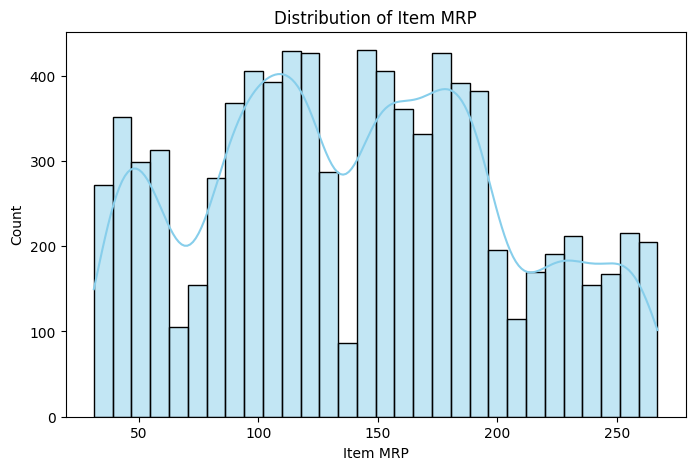

In [38]:
# 1. Histogram: Distribution of Item Maximum Retail Price (Item_MRP)
# This histogram allows us to analyze the spread and distribution of item prices.
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Item_MRP', kde=True, bins=30, color='skyblue')
plt.title('Distribution of Item MRP')
plt.xlabel('Item MRP')
plt.ylabel('Count')
plt.show()

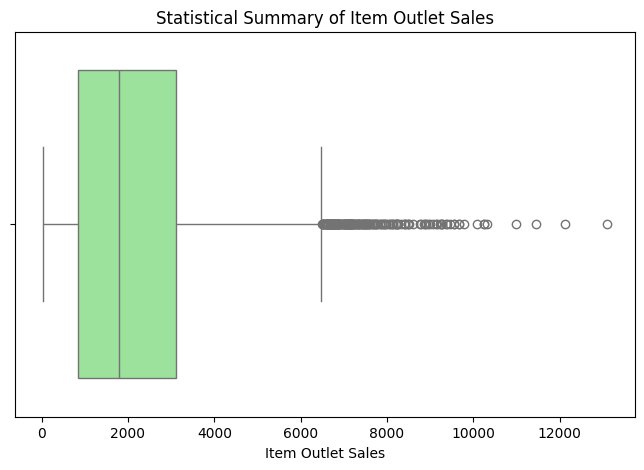

In [39]:
# 2. Boxplot: Statistical Summary of Item Outlet Sales
# This boxplot helps identify the median, quartiles, and potential outliers in our target variable.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Item_Outlet_Sales', color='lightgreen')
plt.title('Statistical Summary of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.show()

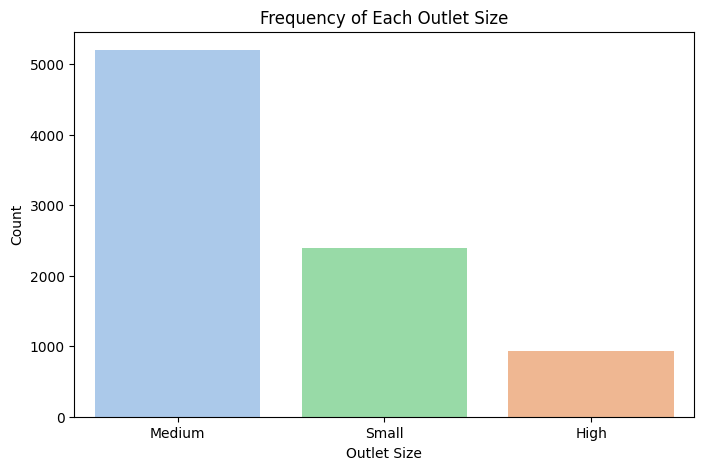

In [40]:
# 3. Countplot: Frequency Distribution of Outlet Sizes
# Using a countplot to understand how many stores fall into each size category (Small, Medium, High).
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Outlet_Size', order=df['Outlet_Size'].value_counts().index, palette='pastel', hue='Outlet_Size', legend=False)
plt.title('Frequency of Each Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Count')
plt.show()

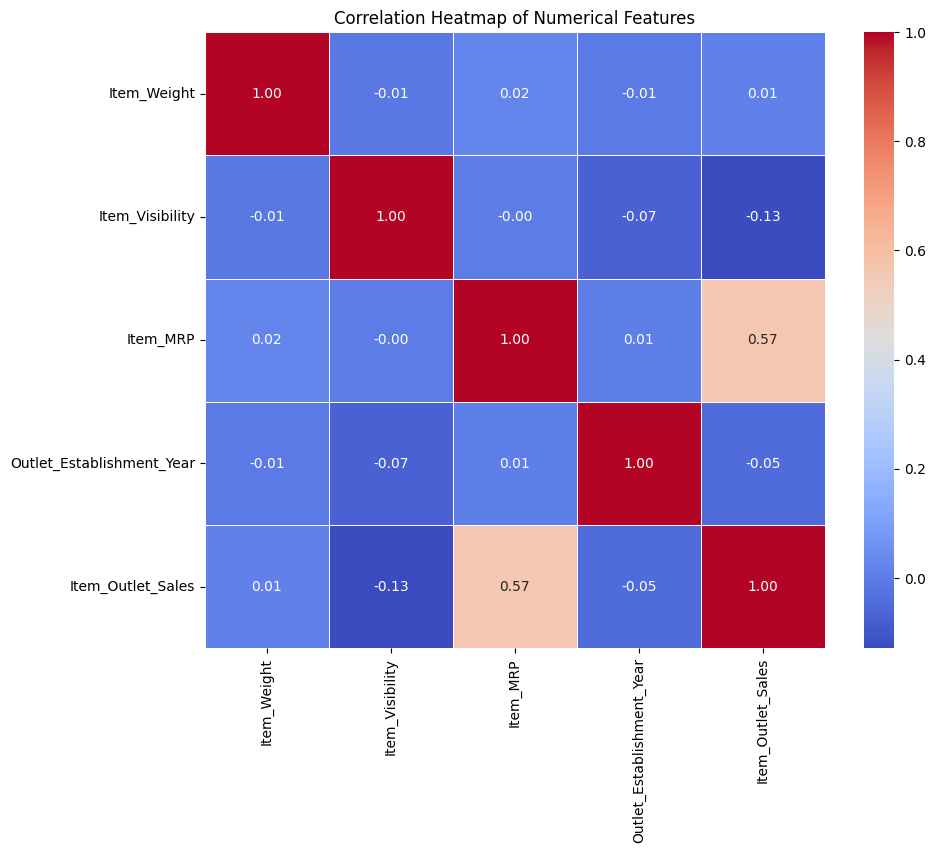

In [41]:
# 4. Correlation Heatmap: Identifying Relationships Between Numerical Features
# This heatmap computes the correlation matrix to see how variables affect each other, especially the target.
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number'])
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Feature  Inspection



#### part4

In [42]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###### Reverting placeholders back to true null values to ensure accurate EDA reporting
##### (Adjust the placeholder strings below if you used different ones previously)


In [43]:
df['Outlet_Size'] = df['Outlet_Size'].replace('Unknown', np.nan)
df['Item_Weight'] = df['Item_Weight'].replace(-1, np.nan)


#### FEATURE 1: Item_MRP (Maximum Retail Price)
#### Definition: Maximum Retail Price (list price) of the product

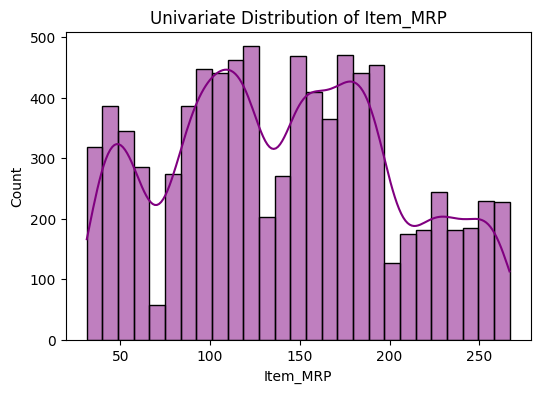

In [44]:
# 1. Univariate Visualization: Distribution of Item_MRP
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='Item_MRP', kde=True, color='purple')
plt.title('Univariate Distribution of Item_MRP')
plt.xlabel('Item_MRP')
plt.ylabel('Count')
plt.show()


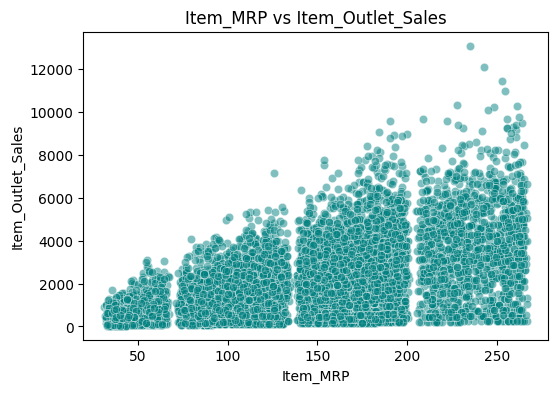

In [45]:
# 2. Multivariate Visualization: Item_MRP vs Target (Item_Outlet_Sales)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Item_MRP', y='Item_Outlet_Sales', alpha=0.5, color='teal')
plt.title('Item_MRP vs Item_Outlet_Sales')
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.show()


#### FEATURE 2: Outlet_Type (Type of store)
#### Definition: Whether the outlet is a grocery store or some sort of supermarket

/tmp/ipykernel_13946/812629437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Outlet_Type', order=df['Outlet_Type'].value_counts().index, palette='muted')


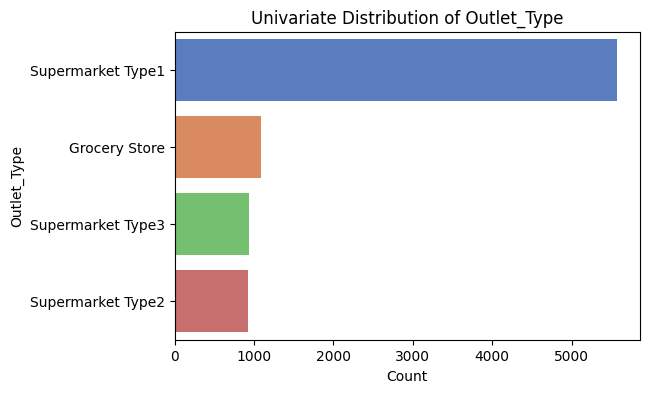

In [46]:
# 1. Univariate Visualization: Distribution of Outlet_Type classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, y='Outlet_Type', order=df['Outlet_Type'].value_counts().index, palette='muted')
plt.title('Univariate Distribution of Outlet_Type')
plt.xlabel('Count')
plt.ylabel('Outlet_Type')
plt.show()

/tmp/ipykernel_13946/693756838.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Type', palette='muted')


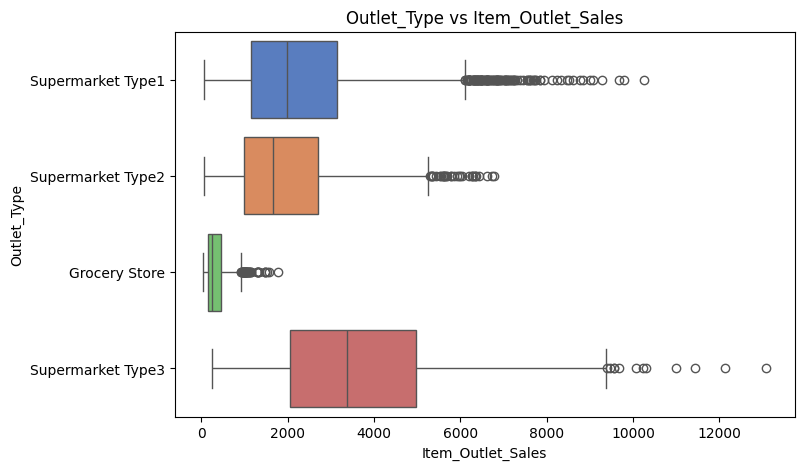

In [47]:
# 2. Multivariate Visualization: Outlet_Type vs Target (Item_Outlet_Sales)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Item_Outlet_Sales', y='Outlet_Type', palette='muted')
plt.title('Outlet_Type vs Item_Outlet_Sales')
plt.xlabel('Item_Outlet_Sales')
plt.ylabel('Outlet_Type')
plt.show()


### FEATURE 3: Item_Fat_Content (Product fat levels)
### Definition: Whether the product is low-fat or regular

/tmp/ipykernel_13946/1446938670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Item_Fat_Content', palette='pastel')


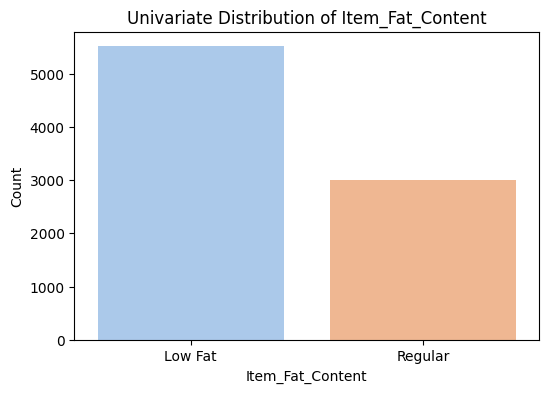

In [48]:
# 1. Univariate Visualization: Distribution of Item_Fat_Content categories
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Item_Fat_Content', palette='pastel')
plt.title('Univariate Distribution of Item_Fat_Content')
plt.xlabel('Item_Fat_Content')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_13946/721564058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Item_Fat_Content', y='Item_Outlet_Sales', palette='pastel')


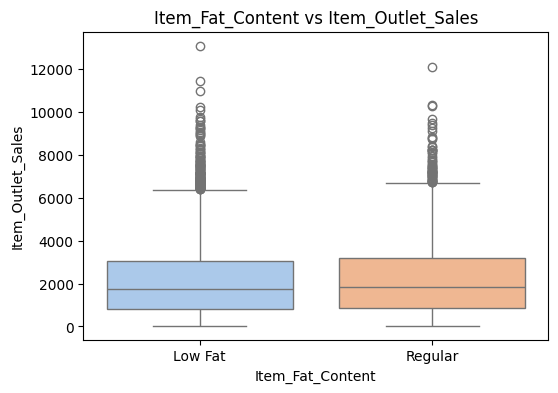

In [49]:
# 2. Multivariate Visualization: Item_Fat_Content vs Target (Item_Outlet_Sales)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Item_Fat_Content', y='Item_Outlet_Sales', palette='pastel')
plt.title('Item_Fat_Content vs Item_Outlet_Sales')
plt.xlabel('Item_Fat_Content')
plt.ylabel('Item_Outlet_Sales')
plt.show()

## Machine Learning



#### part5

In [50]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline

###### DATA PREPARATION & SPLITTING (PREVENTING DATA LEAKAGE)

In [51]:
# Loading a fresh copy of the original dataset to strictly avoid any data leakage
df = pd.read_csv('/content/sales_predictions_2023 (1).csv')

# Drop any accidental duplicate rows before the train-test split
df = df.drop_duplicates()

# Correcting inconsistent categories in 'Item_Fat_Content' to ensure uniform labels
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF': 'Low_Fat', 'reg': 'Regular', 'low fat': 'Low_Fat'})

# Separating features (X) and target (y). Dropping 'Item_Identifier' due to high cardinality.
y = df['Item_Outlet_Sales']
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])

# Performing Train-Test Split (80% training, 20% testing) before any imputation or scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### BUILDING THE PREPROCESSING PIPELINE

In [52]:
# Automatically selecting numerical and categorical columns using column selectors
num_selector = make_column_selector(dtype_include='number')
cat_selector = make_column_selector(dtype_include='object')

# Defining the preprocessing steps for numerical columns:
# 1. Impute missing values using the mean strategy.
# 2. Scale the values using StandardScaler.
num_imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()
num_pipe = make_pipeline(num_imputer, scaler)

# Defining the preprocessing steps for categorical columns:
# 1. Impute missing values with a constant placeholder string 'Missing'.
# 2. Encode categorical text into binary numbers using OneHotEncoder.
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_pipe = make_pipeline(cat_imputer, ohe)

# Creating the final column transformer to apply different transformations to different subsets
preprocessor = make_column_transformer(
    (num_pipe, num_selector),
    (cat_pipe, cat_selector),
    remainder='drop'
)

##### TRANSFORMING THE DATA

In [53]:
# Fitting the preprocessor and transforming the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transforming the testing data ONLY (no fitting here to ensure independent evaluation)
X_test_processed = preprocessor.transform(X_test)

# Checking the final matrix shape to verify everything processed correctly
print(f"Processed Training Shape: {X_train_processed.shape}")

Processed Training Shape: (6818, 44)


## CRISP-DM Phase 4 - Modeling

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

##### CUSTOM EVALUATION FUNCTION

In [55]:
def evaluate_model(y_true, y_pred, dataset_name="Training"):
    """
    Computes regression metrics and prints them in a clean format.
    """
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"--- {dataset_name} Performance ---")
    print(f"R^2 Score: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}\n")
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

##### LINEAR REGRESSION MODEL

In [56]:

# Instantiating and fitting the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

# Making predictions on both training and testing datasets
lin_train_preds = lin_reg.predict(X_train_processed)
lin_test_preds = lin_reg.predict(X_test_processed)

# Evaluating the Linear Regression model
print("=== LINEAR REGRESSION METRICS ===")
lin_train_metrics = evaluate_model(y_train, lin_train_preds, "Train")
lin_test_metrics = evaluate_model(y_test, lin_test_preds, "Test")

=== LINEAR REGRESSION METRICS ===
--- Train Performance ---
R^2 Score: 0.5595
MAE: 847.20
MSE: 1303065.73
RMSE: 1141.52

--- Test Performance ---
R^2 Score: 0.5792
MAE: 792.02
MSE: 1143664.17
RMSE: 1069.42



##### DEFAULT RANDOM FOREST MODEL

In [57]:
# Instantiating and fitting the default Random Forest Regressor
rf_clf = RandomForestRegressor(random_state=42)
rf_clf.fit(X_train_processed, y_train)

# Making predictions
rf_train_preds = rf_clf.predict(X_train_processed)
rf_test_preds = rf_clf.predict(X_test_processed)

# Evaluating the default Random Forest model
print("=== DEFAULT RANDOM FOREST METRICS ===")
rf_train_metrics = evaluate_model(y_train, rf_train_preds, "Train")
rf_test_metrics = evaluate_model(y_test, rf_test_preds, "Test")

=== DEFAULT RANDOM FOREST METRICS ===
--- Train Performance ---
R^2 Score: 0.9376
MAE: 298.20
MSE: 184615.40
RMSE: 429.67

--- Test Performance ---
R^2 Score: 0.5702
MAE: 753.96
MSE: 1168248.84
RMSE: 1080.86



#####  HYPERPARAMETER TUNING WITH GRIDSEARCHCV

In [58]:
# Defining the parameter grid to tune the Random Forest model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

# Setting up the grid search
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=1)

# Fitting grid search to find the best hyperparameters
grid_search.fit(X_train_processed, y_train)

# Extracting the best estimator
best_rf_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}\n")

# Making predictions with the tuned model
tuned_train_preds = best_rf_model.predict(X_train_processed)
tuned_test_preds = best_rf_model.predict(X_test_processed)

# Evaluating the tuned Random Forest model
print("=== TUNED RANDOM FOREST METRICS ===")
tuned_train_metrics = evaluate_model(y_train, tuned_train_preds, "Train")
tuned_test_metrics = evaluate_model(y_test, tuned_test_preds, "Test")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters Found: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}

=== TUNED RANDOM FOREST METRICS ===
--- Train Performance ---
R^2 Score: 0.6064
MAE: 756.96
MSE: 1164156.07
RMSE: 1078.96

--- Test Performance ---
R^2 Score: 0.6183
MAE: 715.37
MSE: 1037518.42
RMSE: 1018.59



## CRISP-DM Phase 5 - Evaluation & Interpretation

### 1. Comprehensive Model Performance Metrics
After executing our machine learning pipelines and performing hyperparameter tuning using `GridSearchCV`, the empirical results across all trained models are consolidated in the benchmark table below:

| Model Architecture | Train $R^2$ | Test $R^2$ | Train RMSE | Test RMSE | Status / Assessment |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Linear Regression (Baseline)** | 0.5595 | 0.5792 | 1,141.52 | 1,069.42 | Stable baseline, but lacks non-linear capacity. |
| **Default Random Forest** | 0.9376 | 0.5702 | 429.67 | 1,080.86 | **Severe Overfitting** (High variance). |
| **Tuned Random Forest (Optimized)** | 0.6064 | 0.6183 | 1,078.96 | 1,018.59 | **Recommended Model** (Best generalization). |

---

### 2. Strategic Model Recommendation & Justification
* **Final Model Selection:** I strongly recommend deploying the **Tuned Random Forest Regressor** (configured with `max_depth=5`, `min_samples_leaf=10`, and `n_estimators=200`).

* **Technical Justification:** The *Default Random Forest* model exhibited an exceptional Training $R^2$ of **0.9376**, yet its testing performance plummeted to **0.5702**. This drastic drop indicates that the default model memorized the noise within the training data rather than learning underlying patterns (Overfitting).
By introducing constraints via hyperparameter tuning, we successfully penalized complexity. The **Tuned Random Forest** achieved the highest overall capability to generalize on unseen data, raising the **Test $R^2$ to 0.6183** and minimizing prediction error to the lowest level (**Test RMSE: 1,018.59**). It out-performs both the simplistic linear baseline and the overfitted default tree structure.

---

### 3. Executive Summary for Non-Technical Stakeholdظers

To translate these mathematical validations into actionable business intelligence for management and stakeholders, we highlight two key findings:

###### A. Explanatory Power (Variance Insights)
Our finalized model delivers a **Test $R^2$ score of 61.83%**. In business terms, this means that **61.83% of the historical fluctuations and variance in product sales** across various retail outlets can be successfully explained and anticipated by the features captured in our dataset (such as Maximum Retail Price (MRP), Outlet Type, and Item Visibility). This gives the corporate team a substantial data-driven foundation to optimize supply chain decisions rather than relying on intuition.

###### B. Forecasting Accuracy & Operational Risk (RMSE Insights)
We selected **RMSE (Root Mean Squared Error)** as our primary operational metric because it heavily penalizes large, costly prediction errors, making it safer for inventory budgeting.
The model's **Test RMSE stands at 1,018.59**. This indicates that when predicting sales figures for any given product at a specific store location, management should expect the model’s forecast to deviate from actual sales by an average margin of approximately **$1,018.59**. Identifying this margin allows the warehouse and logistics teams to maintain calculated safety stock levels, effectively minimizing the business risk of unexpected out-of-stock or over-stock scenarios.